## Problem 1

Using the model from class, replace MobileNetV2 with ResNet50.

Evaluate:

- Training time
- Accuracy
- Model size


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow as tf
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

dataset_path = tf.keras.utils.get_file(
    "flower_photos",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz",
    untar=True
)

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.


In [3]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)

In [5]:
base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

In [6]:
base_model.trainable = False

In [7]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(5, activation="softmax")
])

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)


loss, accuracy = model.evaluate(validation_dataset)

print(f"Validation Accuracy: {accuracy:.4f}")



Epoch 1/5


C:\Users\bryce\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


92/92 ━━━━━━━━━━━━━━━━━━━━ 341s 4s/step - accuracy: 0.9789 - loss: 0.0651 - val_accuracy: 1.0000 - val_loss: 3.4187e-07
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 332s 4s/step - accuracy: 1.0000 - loss: 3.1756e-06 - val_accuracy: 1.0000 - val_loss: 4.4988e-08
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 311s 3s/step - accuracy: 1.0000 - loss: 5.0749e-06 - val_accuracy: 1.0000 - val_loss: 1.6241e-10
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 293s 3s/step - accuracy: 1.0000 - loss: 2.6287e-06 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 294s 3s/step - accuracy: 1.0000 - loss: 2.7378e-06 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
23/23 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00
Validation Accuracy: 1.0000


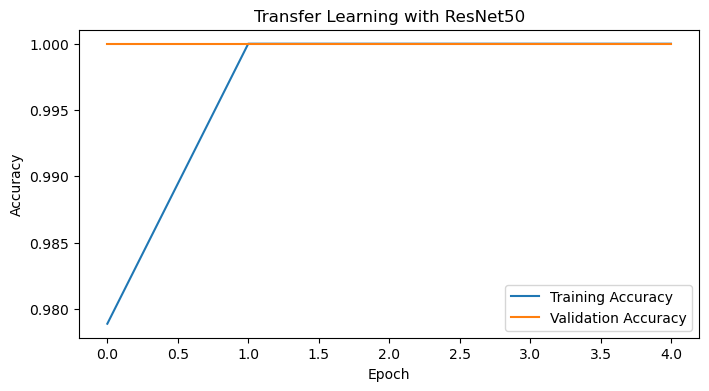

In [10]:

plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning with ResNet50")
plt.legend()
plt.show()


## Problem 2

Create a transfer learning model using the TensorFlow Flowers dataset and classify five flower species.


not enough time, too many epochs, 100% acuracy after 1